# Phase 1 — EDA & Preprocessing
## Hate Speech & Offensive Language Detection on Twitter

### Topic Description
This project focuses on **detecting hate speech and offensive language in social media posts (Twitter)**.
Identifying harmful content on social networks is a critical challenge — platforms need automated tools
to flag toxic posts at scale. This is a multi-class text classification problem.

### Dataset
**Source:** `labeled_data.csv` — tweets labeled by crowd-sourced annotators into three classes:
- **0 — Hate Speech**
- **1 — Offensive Language**
- **2 — Neither**

### This Notebook Covers
1. Loading & inspecting the data
2. Statistical analysis (EDA)
3. Word frequency analysis & word clouds
4. Annotator agreement
5. Preprocessing pipeline
6. Vectorization (TF-IDF)

In [1]:
import subprocess, sys
subprocess.run([sys.executable, '-m', 'pip', 'install', '-q',
                'pandas', 'matplotlib', 'seaborn', 'wordcloud',
                'nltk', 'scikit-learn'])
print('Dependencies installed.')

Dependencies installed.



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import re
import string
from collections import Counter

import nltk
nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('wordnet', quiet=True)
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

from sklearn.feature_extraction.text import TfidfVectorizer

%matplotlib inline
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

STOP_WORDS = set(stopwords.words('english'))
LEMMATIZER = WordNetLemmatizer()

print('All imports ready.')

All imports ready.


---
## 1. Load & Inspect the Data

In [3]:
df = pd.read_csv('../data-sets/labeled_data.csv', index_col=0)
print(f'Shape: {df.shape}')
print(f'Columns: {list(df.columns)}')
df.head()

Shape: (24783, 6)
Columns: ['count', 'hate_speech', 'offensive_language', 'neither', 'class', 'tweet']


,count,hate_speech,offensive_language,neither,class,tweet
0,3,0,0,3,2,!!! RT @mayasolovely: As a woman you shouldn't...
1,3,0,3,0,1,!!!!! RT @mleew17: boy dats cold...tyga dwn ba...
2,3,0,3,0,1,!!!!!!! RT @UrKindOfBrand Dawg!!!! RT @80sbaby...
3,3,0,2,1,1,!!!!!!!!! RT @C_G_Anderson: @viva_based she lo...
4,6,0,6,0,1,!!!!!!!!!!!!! RT @ShenikaRoberts: The shit you...


In [4]:
df.info()
print('\nMissing values:')
print(df.isnull().sum())
print(f'\nDuplicate tweets: {df["tweet"].duplicated().sum()}')

<class 'pandas.DataFrame'>
Index: 24783 entries, 0 to 25296
Data columns (total 6 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   count               24783 non-null  int64
 1   hate_speech         24783 non-null  int64
 2   offensive_language  24783 non-null  int64
 3   neither             24783 non-null  int64
 4   class               24783 non-null  int64
 5   tweet               24783 non-null  str  
dtypes: int64(5), str(1)
memory usage: 1.3 MB

Missing values:
count                 0
hate_speech           0
offensive_language    0
neither               0
class                 0
tweet                 0
dtype: int64

Duplicate tweets: 0


---
## 2. Class Distribution

Class distribution:
  Offensive Language: 19,190 (77.4%)
  Neither: 4,163 (16.8%)
  Hate Speech: 1,430 (5.8%)


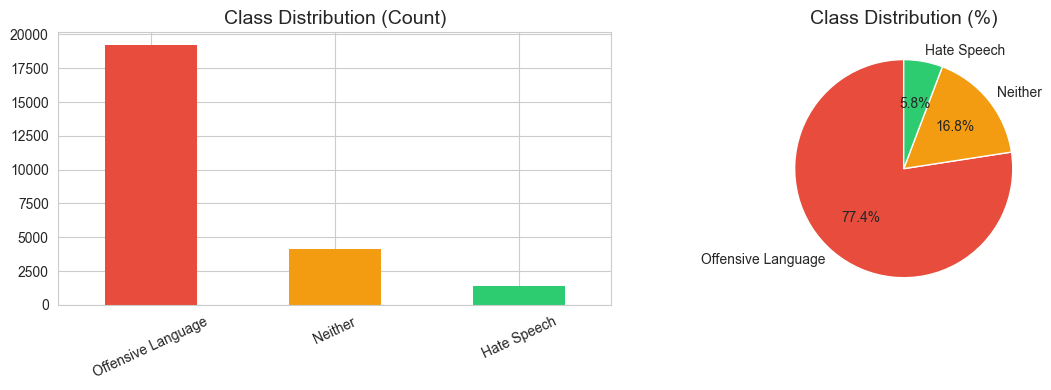


** Note: The dataset is highly imbalanced — Offensive Language dominates (~77%). **


In [5]:
class_names = {0: 'Hate Speech', 1: 'Offensive Language', 2: 'Neither'}
df['class_label'] = df['class'].map(class_names)

class_counts = df['class_label'].value_counts()
class_pcts = df['class_label'].value_counts(normalize=True) * 100

print('Class distribution:')
for label in class_counts.index:
    print(f'  {label}: {class_counts[label]:,} ({class_pcts[label]:.1f}%)')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
colors = ['#e74c3c', '#f39c12', '#2ecc71']

class_counts.plot(kind='bar', ax=axes[0], color=colors, edgecolor='none')
axes[0].set_title('Class Distribution (Count)', fontsize=14)
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=25)

axes[1].pie(class_counts, labels=class_counts.index, autopct='%1.1f%%',
            colors=colors, startangle=90)
axes[1].set_title('Class Distribution (%)', fontsize=14)

plt.tight_layout()
plt.show()

print('\n** Note: The dataset is highly imbalanced — Offensive Language dominates (~77%). **')

---
## 3. Text Statistics

In [6]:
df['char_count'] = df['tweet'].apply(len)
df['word_count'] = df['tweet'].apply(lambda x: len(x.split()))
df['url_count'] = df['tweet'].apply(lambda x: len(re.findall(r'http\S+', x)))
df['mention_count'] = df['tweet'].apply(lambda x: len(re.findall(r'@\w+', x)))
df['hashtag_count'] = df['tweet'].apply(lambda x: len(re.findall(r'#\w+', x)))
df['has_rt'] = df['tweet'].apply(lambda x: 1 if x.strip().startswith('RT') else 0)
df['special_char_count'] = df['tweet'].apply(
    lambda x: sum(1 for c in x if c in string.punctuation))

stats_cols = ['char_count', 'word_count', 'url_count', 'mention_count',
              'hashtag_count', 'special_char_count']
print('Overall text statistics:')
df[stats_cols].describe().round(1)

Overall text statistics:


,char_count,word_count,url_count,mention_count,hashtag_count,special_char_count
count,24783.0,24783.0,24783.0,24783.0,24783.0,24783.0
mean,85.4,14.1,0.1,0.8,0.8,6.3
std,41.5,6.8,0.3,0.9,2.0,7.3
min,5.0,1.0,0.0,0.0,0.0,0.0
25%,52.0,9.0,0.0,0.0,0.0,2.0
50%,81.0,13.0,0.0,1.0,0.0,4.0
75%,119.0,19.0,0.0,1.0,1.0,8.0
max,754.0,52.0,2.0,10.0,77.0,234.0


In [7]:
print('Text statistics by class:')
df.groupby('class_label')[stats_cols].mean().round(1)

Text statistics by class:


,char_count,word_count,url_count,mention_count,hashtag_count,special_char_count
class_label,,,,,,
Hate Speech,84.6,13.9,0.1,0.9,0.5,5.3
Neither,94.9,14.9,0.2,0.8,0.8,7.0
Offensive Language,83.5,14.0,0.1,0.8,0.8,6.3


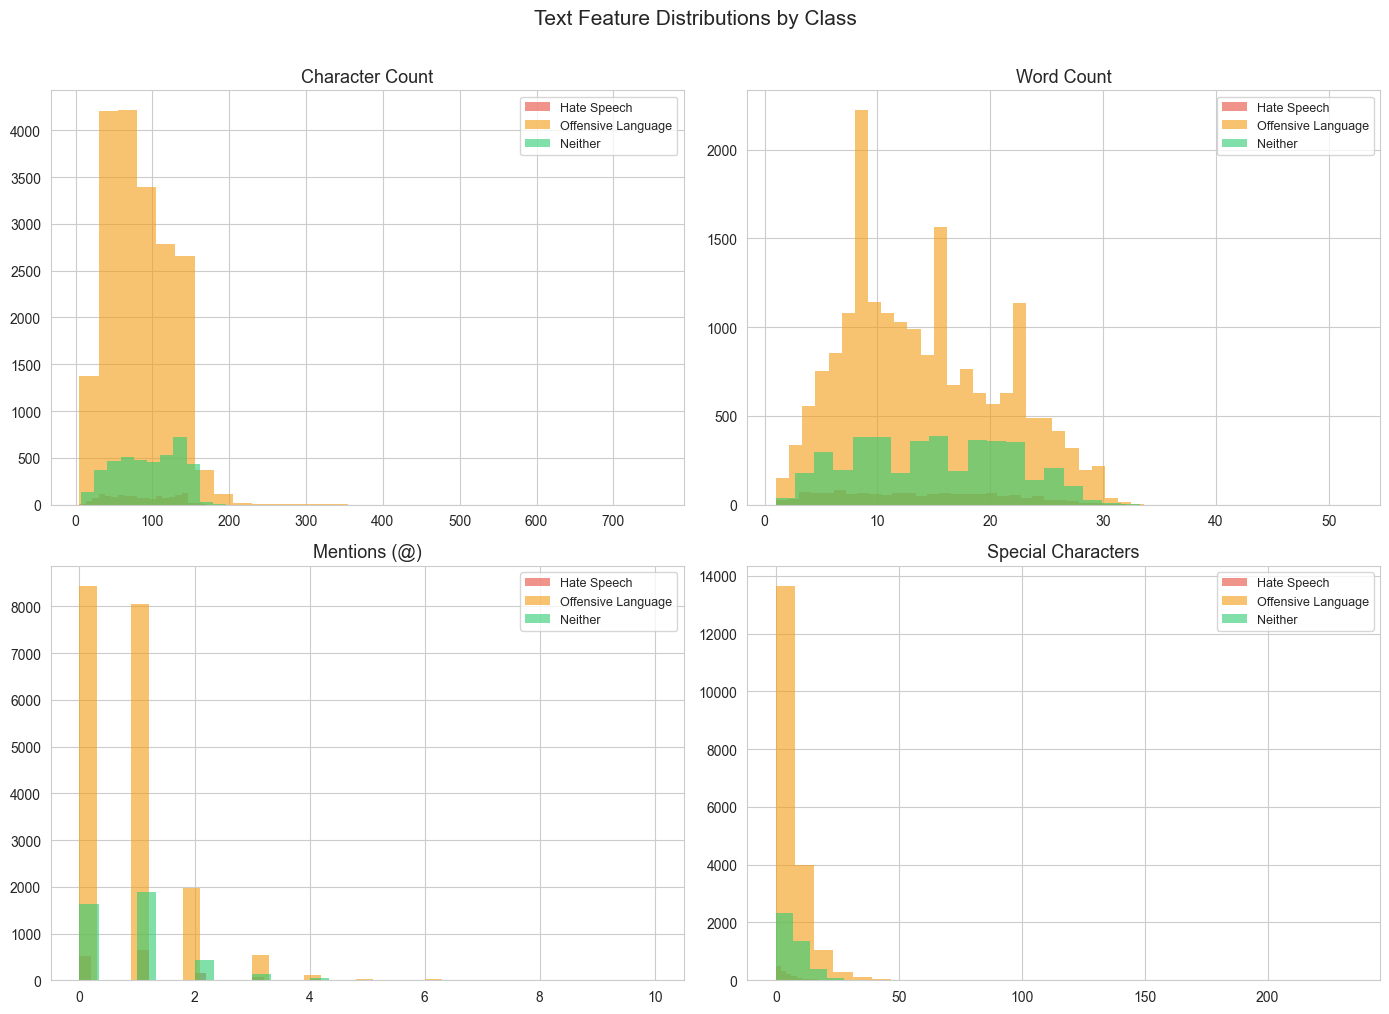

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, col, title in zip(axes.flat,
    ['char_count', 'word_count', 'mention_count', 'special_char_count'],
    ['Character Count', 'Word Count', 'Mentions (@)', 'Special Characters']):
    for cls, color in zip(['Hate Speech', 'Offensive Language', 'Neither'], colors):
        subset = df[df['class_label'] == cls][col]
        ax.hist(subset, bins=30, alpha=0.6, label=cls, color=color, edgecolor='none')
    ax.set_title(title, fontsize=13)
    ax.legend(fontsize=9)

plt.suptitle('Text Feature Distributions by Class', fontsize=15, y=1.01)
plt.tight_layout()
plt.show()

In [9]:
# RT (retweet) ratio per class
rt_ratio = df.groupby('class_label')['has_rt'].mean() * 100
print('Retweet ratio per class:')
for label, pct in rt_ratio.items():
    print(f'  {label}: {pct:.1f}%')

Retweet ratio per class:
  Hate Speech: 18.3%
  Neither: 27.4%
  Offensive Language: 26.5%


---
## 4. Word Frequency Analysis

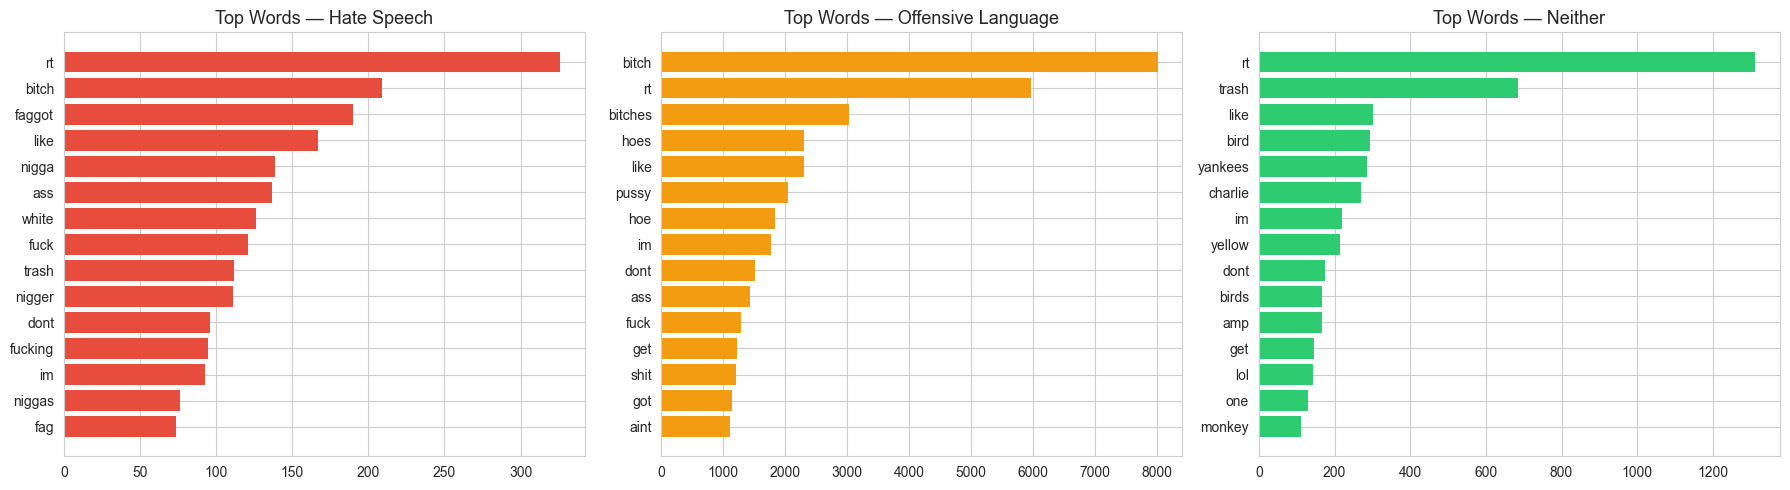

In [10]:
def get_top_words(series, n=20, remove_stopwords=True):
    """Return top n words from a series of text."""
    all_words = []
    for text in series.dropna():
        tokens = text.lower().split()
        tokens = [re.sub(r'[^a-z]', '', w) for w in tokens]
        tokens = [w for w in tokens if len(w) > 1]
        if remove_stopwords:
            tokens = [w for w in tokens if w not in STOP_WORDS]
        all_words.extend(tokens)
    return Counter(all_words).most_common(n)

# Top words per class
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (cls, color) in zip(axes, zip(['Hate Speech', 'Offensive Language', 'Neither'], colors)):
    subset = df[df['class_label'] == cls]['tweet']
    top = get_top_words(subset, n=15)
    words, counts = zip(*top)
    ax.barh(list(reversed(words)), list(reversed(counts)), color=color, edgecolor='none')
    ax.set_title(f'Top Words — {cls}', fontsize=13)

plt.tight_layout()
plt.show()

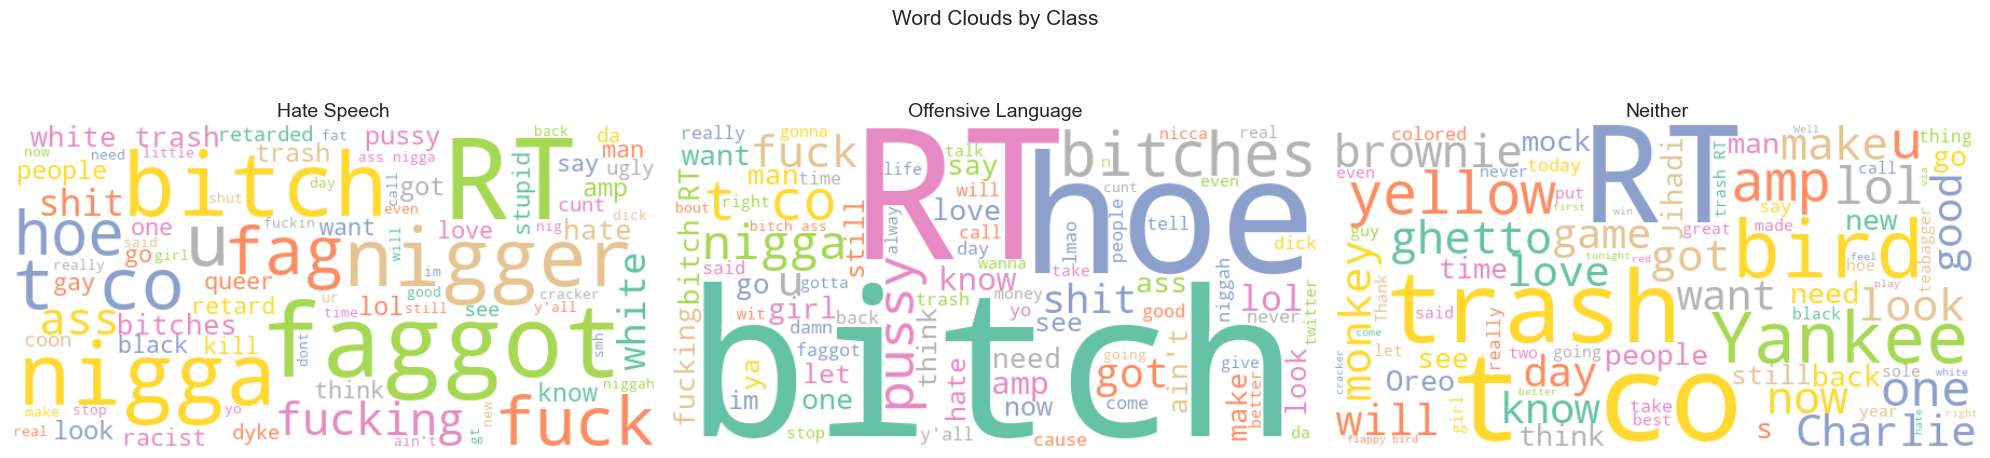

In [11]:
# Word clouds per class
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

for ax, cls in zip(axes, ['Hate Speech', 'Offensive Language', 'Neither']):
    text = ' '.join(df[df['class_label'] == cls]['tweet'].dropna())
    wc = WordCloud(width=600, height=300, background_color='white',
                   max_words=80, colormap='Set2').generate(text)
    ax.imshow(wc, interpolation='bilinear')
    ax.set_title(cls, fontsize=14)
    ax.axis('off')

plt.suptitle('Word Clouds by Class', fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

---
## 5. Annotator Agreement

Average annotator agreement: 90.50%
Unanimous agreement (100%): 17,482 tweets (70.5%)


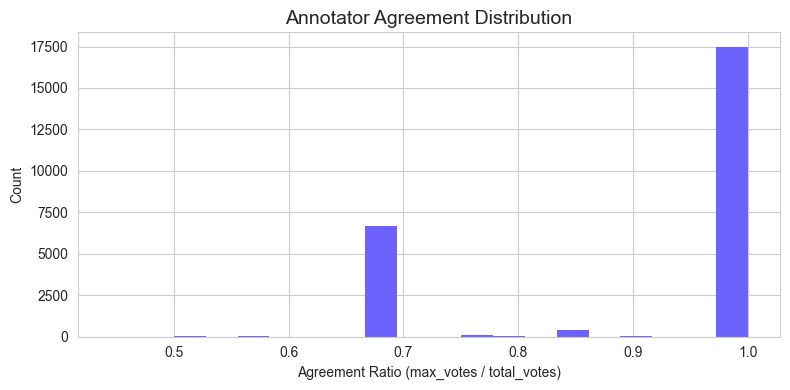

In [12]:
# Each tweet was labeled by 'count' annotators
# The class is determined by majority vote
df['agreement_ratio'] = df[['hate_speech', 'offensive_language', 'neither']].max(axis=1) / df['count']

print(f'Average annotator agreement: {df["agreement_ratio"].mean():.2%}')
print(f'Unanimous agreement (100%): {(df["agreement_ratio"] == 1.0).sum():,} tweets '
      f'({(df["agreement_ratio"] == 1.0).mean():.1%})')

fig, ax = plt.subplots(figsize=(8, 4))
df['agreement_ratio'].hist(bins=20, ax=ax, color='#6C63FF', edgecolor='none')
ax.set_title('Annotator Agreement Distribution', fontsize=14)
ax.set_xlabel('Agreement Ratio (max_votes / total_votes)')
ax.set_ylabel('Count')
plt.tight_layout()
plt.show()

In [13]:
# Agreement by class
print('Average agreement ratio by class:')
for cls in ['Hate Speech', 'Offensive Language', 'Neither']:
    avg = df[df['class_label'] == cls]['agreement_ratio'].mean()
    print(f'  {cls}: {avg:.2%}')

Average agreement ratio by class:
  Hate Speech: 72.80%
  Offensive Language: 91.95%
  Neither: 89.87%


---
## 6. Preprocessing

The following steps are applied to each tweet:

| Step | Tool/Method | Description |
|------|------------|-------------|
| 1 | `str.lower()` | Convert to lowercase |
| 2 | `re.sub()` | Remove URLs |
| 3 | `re.sub()` | Remove @mentions |
| 4 | `re.sub()` | Remove RT prefix |
| 5 | `re.sub()` | Remove HTML entities (&amp; etc.) |
| 6 | `str.replace()` | Remove # symbol (keep word) |
| 7 | `re.sub()` | Remove punctuation & special characters |
| 8 | `re.sub()` | Remove extra whitespace |
| 9 | `nltk.word_tokenize()` | Tokenization |
| 10 | `nltk.stopwords` | Remove English stopwords |
| 11 | `WordNetLemmatizer` | Lemmatization |

In [14]:
def preprocess_tweet(text):
    """Full preprocessing pipeline for a single tweet."""
    # 1. Lowercase
    text = text.lower()
    # 2. Remove URLs
    text = re.sub(r'http\S+|www\S+', '', text)
    # 3. Remove mentions (@user)
    text = re.sub(r'@\w+', '', text)
    # 4. Remove RT prefix
    text = re.sub(r'^rt\s+', '', text)
    # 5. Remove HTML entities (&amp; etc.)
    text = re.sub(r'&\w+;', '', text)
    # 6. Remove hashtag symbol (keep the word)
    text = text.replace('#', '')
    # 7. Remove punctuation and special characters
    text = re.sub(r'[^a-z\s]', '', text)
    # 8. Remove extra whitespace
    text = re.sub(r'\s+', ' ', text).strip()
    # 9. Tokenize
    tokens = word_tokenize(text)
    # 10. Remove stopwords
    tokens = [w for w in tokens if w not in STOP_WORDS and len(w) > 1]
    # 11. Lemmatize
    tokens = [LEMMATIZER.lemmatize(w) for w in tokens]
    return ' '.join(tokens)

# Show examples before & after
print('=== Preprocessing Examples ===')
for i in [0, 1, 5, 100]:
    original = df.iloc[i]['tweet']
    cleaned = preprocess_tweet(original)
    print(f'\nOriginal:  {original[:120]}')
    print(f'Cleaned:   {cleaned[:120]}')
    print('-' * 60)

=== Preprocessing Examples ===

Original:  !!! RT @mayasolovely: As a woman you shouldn't complain about cleaning up your house. &amp; as a man you should always t
Cleaned:   rt woman shouldnt complain cleaning house man always take trash
------------------------------------------------------------

Original:  !!!!! RT @mleew17: boy dats cold...tyga dwn bad for cuffin dat hoe in the 1st place!!
Cleaned:   rt boy dat coldtyga dwn bad cuffin dat hoe st place
------------------------------------------------------------

Original:  !!!!!!!!!!!!!!!!!!"@T_Madison_x: The shit just blows me..claim you so faithful and down for somebody but still fucking w
Cleaned:   shit blow meclaim faithful somebody still fucking hoe
------------------------------------------------------------

Original:  "@ClicquotSuave: LMAOOOOOOOOOOO this nigga @Krillz_Nuh_Care http://t.co/AAnpSUjmYI" &lt;bitch want likes for some depres
Cleaned:   lmaooooooooooo nigga bitch want like depressing shitfoh
-------------------

In [15]:
# Apply preprocessing to all tweets
df['tweet_clean'] = df['tweet'].apply(preprocess_tweet)

# Check for empty tweets after cleaning
empty_count = (df['tweet_clean'].str.strip() == '').sum()
print(f'Empty tweets after cleaning: {empty_count}')

df['clean_word_count'] = df['tweet_clean'].apply(lambda x: len(x.split()) if x.strip() else 0)

print(f'\nBefore preprocessing — avg words per tweet: {df["word_count"].mean():.1f}')
print(f'After preprocessing  — avg words per tweet: {df["clean_word_count"].mean():.1f}')

df[['tweet', 'tweet_clean', 'class_label']].head(10)

Empty tweets after cleaning: 2

Before preprocessing — avg words per tweet: 14.1
After preprocessing  — avg words per tweet: 7.6


,tweet,tweet_clean,class_label
0,!!! RT @mayasolovely: As a woman you shouldn't...,rt woman shouldnt complain cleaning house man ...,Neither
1,!!!!! RT @mleew17: boy dats cold...tyga dwn ba...,rt boy dat coldtyga dwn bad cuffin dat hoe st ...,Offensive Language
2,!!!!!!! RT @UrKindOfBrand Dawg!!!! RT @80sbaby...,rt dawg rt ever fuck bitch start cry confused ...,Offensive Language
3,!!!!!!!!! RT @C_G_Anderson: @viva_based she lo...,rt look like tranny,Offensive Language
4,!!!!!!!!!!!!! RT @ShenikaRoberts: The shit you...,rt shit hear might true might faker bitch told ya,Offensive Language
5,"!!!!!!!!!!!!!!!!!!""@T_Madison_x: The shit just...",shit blow meclaim faithful somebody still fuck...,Offensive Language
6,"!!!!!!""@__BrighterDays: I can not just sit up ...",sit hate another bitch got much shit going,Offensive Language
7,!!!!&#8220;@selfiequeenbri: cause I'm tired of...,cause im tired big bitch coming u skinny girl,Offensive Language
8,""" &amp; you might not get ya bitch back &amp; ...",might get ya bitch back thats,Offensive Language
9,""" @rhythmixx_ :hobbies include: fighting Maria...",hobby include fighting mariam bitch,Offensive Language


---
## 7. Vectorization — TF-IDF

We convert the cleaned text into a numerical vector representation using **TF-IDF** (Term Frequency — Inverse Document Frequency) with unigrams and bigrams.

In [16]:
tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))
X_tfidf = tfidf.fit_transform(df['tweet_clean'])

print(f'TF-IDF matrix shape: {X_tfidf.shape}')
print(f'  Rows (tweets): {X_tfidf.shape[0]:,}')
print(f'  Features (terms): {X_tfidf.shape[1]:,}')
print(f'  Sparsity: {1 - X_tfidf.nnz / (X_tfidf.shape[0] * X_tfidf.shape[1]):.4%}')

TF-IDF matrix shape: (24783, 5000)
  Rows (tweets): 24,783
  Features (terms): 5,000
  Sparsity: 99.8503%


In [17]:
# Top TF-IDF terms per class
print('Top 10 TF-IDF terms per class:')
feature_names = tfidf.get_feature_names_out()
for cls_id, cls_name in class_names.items():
    mask = (df['class'] == cls_id).values
    mean_tfidf = np.asarray(X_tfidf[mask].mean(axis=0)).flatten()
    top_idx = mean_tfidf.argsort()[-10:][::-1]
    top_terms = [(feature_names[i], mean_tfidf[i]) for i in top_idx]
    print(f'\n  {cls_name}:')
    for term, score in top_terms:
        print(f'    {term:20s} {score:.4f}')

Top 10 TF-IDF terms per class:

  Hate Speech:
    faggot               0.0657
    nigger               0.0428
    fag                  0.0396
    nigga                0.0278
    white                0.0253
    trash                0.0207
    like                 0.0196
    bitch                0.0196
    as                   0.0185
    fuck                 0.0184

  Offensive Language:
    bitch                0.0771
    hoe                  0.0424
    pussy                0.0268
    like                 0.0205
    im                   0.0182
    nigga                0.0173
    got                  0.0151
    as                   0.0151
    fuck                 0.0149
    dont                 0.0147

  Neither:
    trash                0.0515
    bird                 0.0335
    yankee               0.0215
    charlie              0.0202
    yellow               0.0191
    like                 0.0126
    oreo                 0.0120
    brownie              0.0118
    monkey            

---
## Summary

| Property | Value |
|----------|-------|
| Dataset | `labeled_data.csv` |
| Source | Twitter |
| Total samples | ~24,783 |
| Classes | 3 (Hate Speech / Offensive / Neither) |
| Balanced? | No — 77% Offensive, 17% Neither, 6% Hate Speech |
| Preprocessing | Lowercase, remove URLs/mentions/RT/HTML/punctuation, tokenize, stopwords, lemmatize |
| Vectorization | TF-IDF (5,000 features, unigrams + bigrams) |
| Output format | Sparse TF-IDF matrix — ready for ML models |

**Key challenge:** Class imbalance — will need to address in Phase 2 (e.g., oversampling, class weights).